# Tarea 2: Regresión no lineal y MLE

MDS7104: Aprendizaje de Maquinas - Otoño 2026

---

### Cuerpo Docente:

- Profesor: Francisco Vásquez L.
- Auxiliares: Álvaro Márquez y Diego Olguín Wende
- Ayudantes: Javiera Yañez y Tamara Carrasco


### Estudiante

- Felipe Muñoz M.

In [1]:
!uv add numpy requests pandas matplotlib scipy scikit-learn ruff pre-commit

Resolved 63 packages in 20ms
Audited 58 packages in 16ms


In [2]:
!uv add ipykernel ipython matplotlib-inline

Resolved 63 packages in 3ms
Audited 58 packages in 1ms


In [3]:
import json
import os

import matplotlib
import numpy as np
import pandas as pd

os.environ.pop("MPLBACKEND", None)


matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import beta as beta_dist
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
%matplotlib inline

# P1: Modelo de Inferencia Bayesiana

3. Evolución de la distribución posterior y consistencia bayesiana en el modelo Beta-Bernoulli

In [5]:
# Semilla RUT
RUT = 208578189
np.random.seed(RUT)

# Parámetros
theta_true = 0.7
n = 1000
k_values = [1, 5, 10, 25, 50, 100, 500, 1000]

# Generar datos
datos = np.random.binomial(1, theta_true, n)

# Priors: (alpha, beta, nombre, color)
priors = [
    (1, 1, r"Beta(1,1) — Uniforme", "#2196F3"),
    (5, 1, r"Beta(5,1) — Optimista", "#FF9800"),
    (1, 5, r"Beta(1,5) — Pesimista", "#9C27B0"),
    (10, 10, r"Beta(10,10) — Concentrado en 0.5", "#4CAF50"),
]

Se Implementan algunas funciones auxiliares

In [6]:
def get_posterior_params(alpha0, beta0, k, datos):
    s = datos[:k].sum()
    return alpha0 + s, beta0 + k - s


def posterior_mean(alpha, beta):
    return alpha / (alpha + beta)


def posterior_map(alpha, beta):
    if alpha <= 1 or beta <= 1:
        return None  # MAP no bien definido
    return (alpha - 1) / (alpha + beta - 2)


def credible_interval(alpha, beta, level=0.95):
    lo = (1 - level) / 2
    hi = 1 - lo
    return beta_dist.ppf(lo, alpha, beta), beta_dist.ppf(hi, alpha, beta)

Se realiza el primer gráfico, de posteriors en cada k (número de observaciones) para cada prior

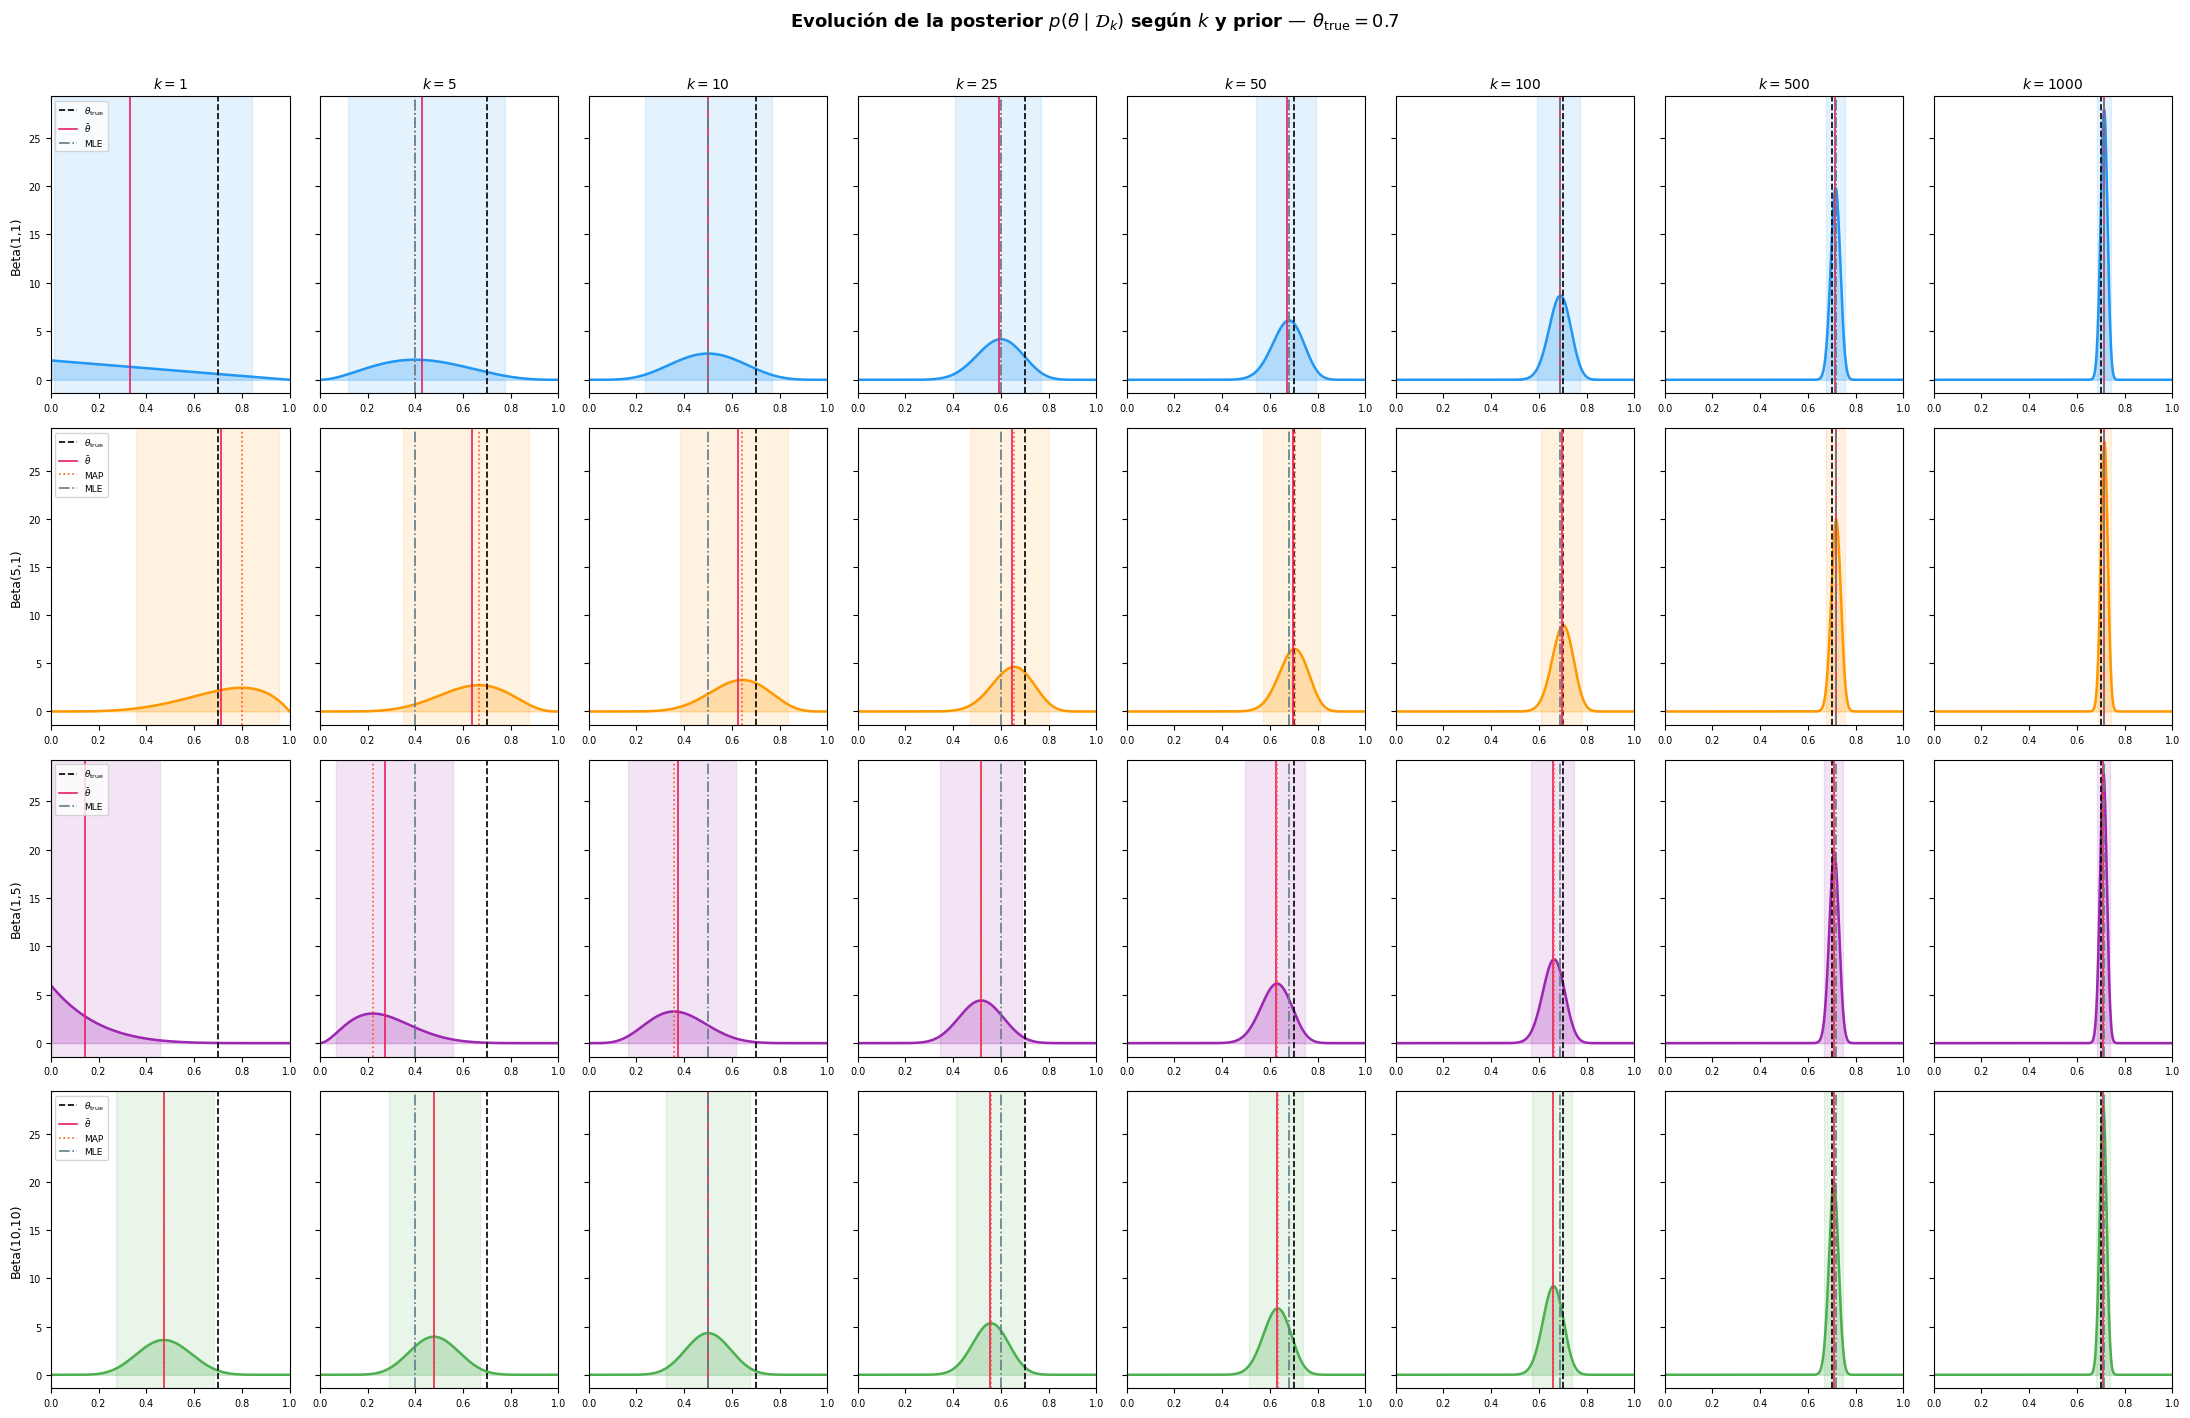

In [7]:
theta_grid = np.linspace(0.001, 0.999, 500)

fig, axes = plt.subplots(len(priors), len(k_values), figsize=(22, 14), sharey="row")

cmap = plt.cm.viridis
colors_k = [cmap(i / (len(k_values) - 1)) for i in range(len(k_values))]

for row, (a0, b0, name, color) in enumerate(priors):
    for col, k in enumerate(k_values):
        ax = axes[row, col]
        a_post, b_post = get_posterior_params(a0, b0, k, datos)
        s = datos[:k].sum()

        # Posterior
        pdf = beta_dist.pdf(theta_grid, a_post, b_post)
        ax.plot(theta_grid, pdf, color=color, lw=1.8)
        ax.fill_between(theta_grid, pdf, alpha=0.25, color=color)

        # Líneas de referencia
        mean_val = posterior_mean(a_post, b_post)
        map_val = posterior_map(a_post, b_post)
        mle_val = s / k if k > 0 else np.nan

        ax.axvline(theta_true, color="black", lw=1.2, ls="--", label=r"$\theta_{\rm true}$")
        ax.axvline(mean_val, color="#E91E63", lw=1.2, ls="-", label=r"$\bar\theta$")
        if map_val is not None:
            ax.axvline(map_val, color="#FF5722", lw=1.2, ls=":", label="MAP")
        ax.axvline(mle_val, color="#607D8B", lw=1.2, ls="-.", label="MLE")

        # Intervalo de credibilidad
        lo, hi = credible_interval(a_post, b_post)
        ax.axvspan(lo, hi, alpha=0.12, color=color)

        # Títulos y etiquetas
        if row == 0:
            ax.set_title(f"$k={k}$", fontsize=10, fontweight="bold")
        if col == 0:
            ax.set_ylabel(name.split("—")[0].strip(), fontsize=9)
        ax.set_xlim(0, 1)
        ax.tick_params(labelsize=7)

        # Leyenda solo en primer panel de cada fila
        if col == 0:
            ax.legend(fontsize=6.5, loc="upper left")

fig.suptitle(
    r"Evolución de la posterior $p(\theta \mid \mathcal{D}_k)$ "
    r"según $k$ y prior — $\theta_{\rm true}=0.7$",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)  # noqa: B018
plt.tight_layout()
plt.savefig("fig1_posteriors.pdf", bbox_inches="tight", dpi=150)
plt.show()

Se realiza el segundo gráfico, que corresponde a la evolución de media, MAP, MLE e IC en función de k (Número de observaciones)

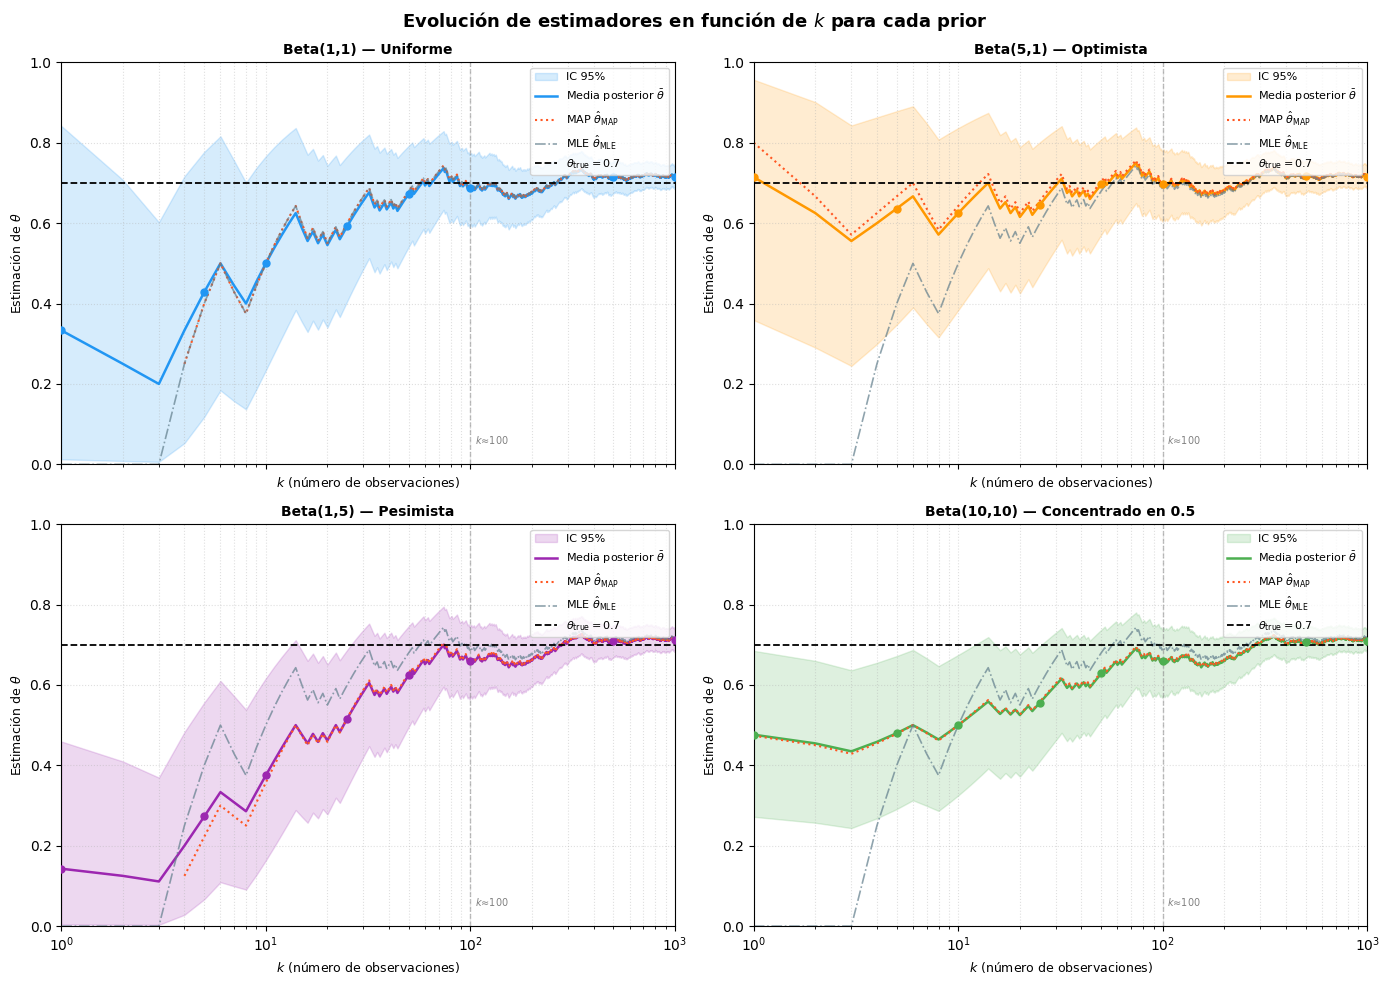

In [8]:
k_fine = np.arange(1, n + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

for idx, (a0, b0, name, color) in enumerate(priors):
    ax = axes[idx]

    means, maps, mles, lo_ci, hi_ci = [], [], [], [], []

    for k in k_fine:
        a_post, b_post = get_posterior_params(a0, b0, k, datos)
        s = datos[:k].sum()

        means.append(posterior_mean(a_post, b_post))
        map_val = posterior_map(a_post, b_post)
        maps.append(map_val if map_val is not None else np.nan)
        mles.append(s / k)
        lo, hi = credible_interval(a_post, b_post)
        lo_ci.append(lo)
        hi_ci.append(hi)

    means = np.array(means)
    maps = np.array(maps)
    mles = np.array(mles)
    lo_ci = np.array(lo_ci)
    hi_ci = np.array(hi_ci)

    # Banda de credibilidad
    ax.fill_between(k_fine, lo_ci, hi_ci, alpha=0.18, color=color, label="IC 95%")

    # Curvas
    ax.plot(k_fine, means, color=color, lw=1.8, label=r"Media posterior $\bar\theta$")
    ax.plot(k_fine, maps, color="#FF5722", lw=1.5, ls=":", label=r"MAP $\hat\theta_{\rm MAP}$")
    ax.plot(k_fine, mles, color="#607D8B", lw=1.2, ls="-.", alpha=0.7, label=r"MLE $\hat\theta_{\rm MLE}$")
    ax.axhline(theta_true, color="black", lw=1.3, ls="--", label=r"$\theta_{\rm true}=0.7$")

    # Marcadores en k_values
    for k in k_values:
        a_post, b_post = get_posterior_params(a0, b0, k, datos)
        ax.plot(k, posterior_mean(a_post, b_post), "o", color=color, ms=5, zorder=5)

    ax.set_xscale("log")
    ax.set_ylim(0, 1)
    ax.set_xlim(1, n)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("$k$ (número de observaciones)", fontsize=9)
    ax.set_ylabel(r"Estimación de $\theta$", fontsize=9)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, which="both", ls=":", alpha=0.4)

    # Línea vertical indicativa de convergencia (~100)
    ax.axvline(100, color="gray", lw=1, ls="--", alpha=0.5)
    ax.text(105, 0.05, "$k≈100$", fontsize=7, color="gray")

fig.suptitle(r"Evolución de estimadores en función de $k$ para cada prior", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig2_evolucion.pdf", bbox_inches="tight", dpi=150)
plt.show()

# P2: Regresión no lineal

## a) Exploración de datos

Se procede a importar la base de datos desde mi repositorio en Github

In [9]:
# Se abre el Dataframe
with open("data_t2_p2.json") as f:
    data = json.load(f)

In [10]:
# Se guardan los datasets de acuerdo a su frecuencia (daily, weekly, monthly)

df_daily = pd.DataFrame(data["daily"]["data"])
df_weekly = pd.DataFrame(data["weekly"]["data"])
df_monthly = pd.DataFrame(data["monthly"]["data"])

# daily y monthly sí tienen "date"
df_daily["date"] = pd.to_datetime(df_daily["date"])
df_monthly["date"] = pd.to_datetime(df_monthly["date"])

# weekly tiene "week_start" y "week_end"
df_weekly["week_start"] = pd.to_datetime(df_weekly["week_start"])
df_weekly["week_end"] = pd.to_datetime(df_weekly["week_end"])

df_daily = df_daily.sort_values("date").reset_index(drop=True)
df_weekly = df_weekly.sort_values("week_start").reset_index(drop=True)
df_monthly = df_monthly.sort_values("date").reset_index(drop=True)

In [11]:
frec = ["daily", "weekly", "monthly"]
for f in frec:
    print(f"Dataset: {f}")
    display(globals()[f"df_{f}"].head())

Dataset: daily


,index,date,review_count
0,1,2009-01-01,0
1,2,2009-01-02,0
2,3,2009-01-03,1
3,4,2009-01-04,0
4,5,2009-01-05,3


Dataset: weekly


,index,week_start,week_end,review_count
0,1,2008-12-29,2009-01-04,1
1,2,2009-01-05,2009-01-11,14
2,3,2009-01-12,2009-01-18,5
3,4,2009-01-19,2009-01-25,2
4,5,2009-01-26,2009-02-01,5


Dataset: monthly


,index,year,month,date,review_count
0,1,2009,1,2009-01-01,27
1,2,2009,2,2009-02-01,5
2,3,2009,3,2009-03-01,8
3,4,2009,4,2009-04-01,4
4,5,2009,5,2009-05-01,8


Se realizará un histograma para cada dataset

/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/3301253663.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


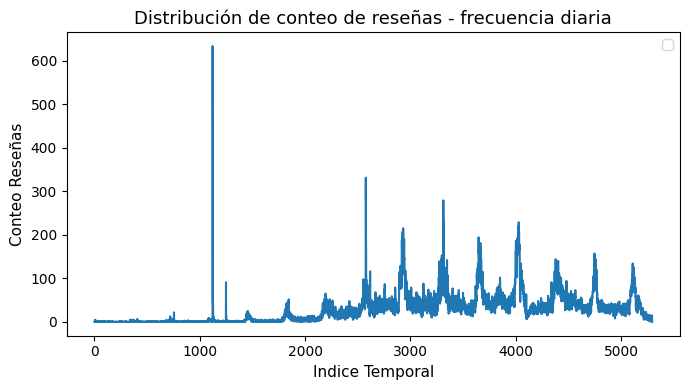

In [12]:
# Daily
fig, ax = plt.subplots(figsize=(7, 4))

# ax.hist(df_daily["review_count"], edgecolor="black", color="steelblue", alpha=0.85)
ax.plot(df_daily["index"], df_daily["review_count"])

ax.set_xlabel("Indice Temporal", fontsize=11)
ax.set_ylabel("Conteo Reseñas", fontsize=11)
ax.set_title("Distribución de conteo de reseñas - frecuencia diaria", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("review_count.png", dpi=150)
plt.show()

/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/526816978.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


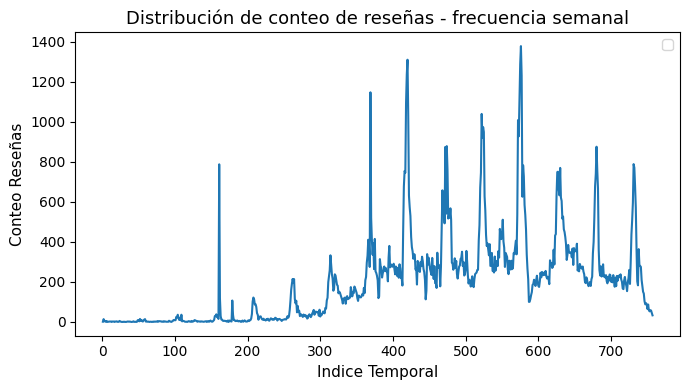

In [13]:
# weekly
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(df_weekly["index"], df_weekly["review_count"])

ax.set_xlabel("Indice Temporal", fontsize=11)
ax.set_ylabel("Conteo Reseñas", fontsize=11)
ax.set_title("Distribución de conteo de reseñas - frecuencia semanal", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("review_count.png", dpi=150)
plt.show()

/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/1739028170.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


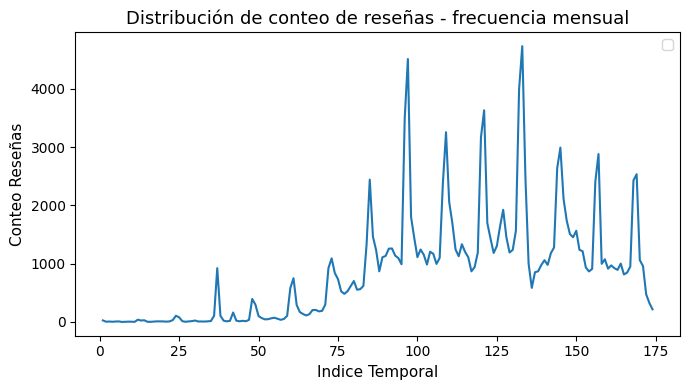

In [14]:
# monthly
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(df_monthly["index"], df_monthly["review_count"])


ax.set_xlabel("Indice Temporal", fontsize=11)
ax.set_ylabel("Conteo Reseñas", fontsize=11)
ax.set_title("Distribución de conteo de reseñas - frecuencia mensual", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("review_count.png", dpi=150)
plt.show()

Se seleccionará la granulación semanal, pues en la diaria, se identifica una dispersión grande en los datos (tipo outliers), en especial cerca del día 1000, lo que puede generar problemas al entrenar el modelo, por otro lado, en la frecuencia mensual existe poca cantidad de datos. Así que el punto intermedio es la granulación semanal. 

Por lo tanto, se procede a separar el 75 % de los datos para entrenamiento (primeros datos cronológicamente) y el 25% en testeo. 

In [15]:
# Partición de los datos semanales
indice_train = int(len(df_weekly) * 0.75)
train = df_weekly[df_weekly["index"] <= indice_train]
test = df_weekly[df_weekly["index"] > indice_train]

X_train, y_train = train[["index"]], train["review_count"]
X_test, y_test = test[["index"]], test["review_count"]

Luego, se procede a gráficar los datos de entrenamiento y de test

/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/3793186399.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


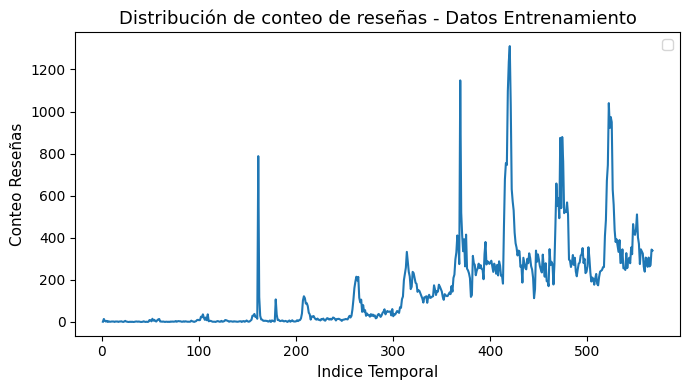

In [16]:
# Gráfico datos Entrenamiento
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(X_train, y_train)

ax.set_xlabel("Indice Temporal", fontsize=11)
ax.set_ylabel("Conteo Reseñas", fontsize=11)
ax.set_title("Distribución de conteo de reseñas - Datos Entrenamiento", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("review_count.png", dpi=150)
plt.show()

/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/4043194122.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


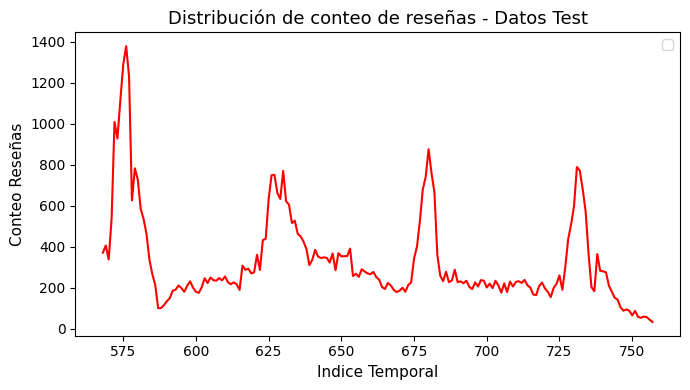

In [17]:
# Gráfico datos Test
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(X_test, y_test, color="red")

ax.set_xlabel("Indice Temporal", fontsize=11)
ax.set_ylabel("Conteo Reseñas", fontsize=11)
ax.set_title("Distribución de conteo de reseñas - Datos Test", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("review_count.png", dpi=150)
plt.show()

## b) Implementar polyfit de numpy 

In [18]:
grados = [1, 2, 3, 4, 5]
colores = ["#E91E63", "#FF9800", "#4CAF50", "#2196F3", "#9C27B0"]

# Se obtienen los valores de X e y para entrenamiento y test de las matrices creadas previamente
x_train = X_train["index"].values
x_test = X_test["index"].values
y_train_vals = y_train.values
y_test_vals = y_test.values

# Ajuste de polinomios usando los datos de entrenamiento
coefs = {}
for grado in grados:
    coefs[grado] = np.polyfit(x_train, y_train_vals, grado)

# Grilla suave para graficar curvas
x_grid_train = np.linspace(x_train.min(), x_train.max(), 500)
x_grid_test = np.linspace(x_test.min(), x_test.max(), 500)

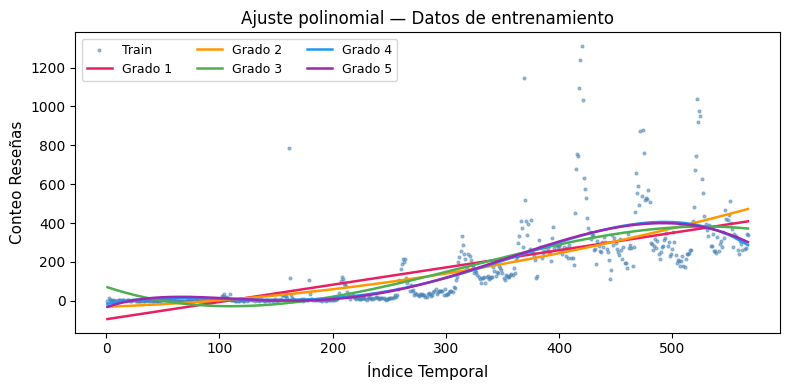

In [19]:
# Ajuste sobre datos de entrenamiento
fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(x_train, y_train_vals, s=4, color="steelblue", alpha=0.5, label="Train", zorder=2)

for grado, color in zip(grados, colores, strict=False):
    y_pred = np.polyval(coefs[grado], x_grid_train)
    ax.plot(x_grid_train, y_pred, color=color, lw=1.8, label=f"Grado {grado}")

ax.set_xlabel("Índice Temporal", fontsize=11)
ax.set_ylabel("Conteo Reseñas", fontsize=11)
ax.set_title("Ajuste polinomial — Datos de entrenamiento", fontsize=12)
ax.legend(fontsize=9, ncol=3)
plt.tight_layout()
plt.savefig("poly_train.pdf", bbox_inches="tight", dpi=150)
plt.show()

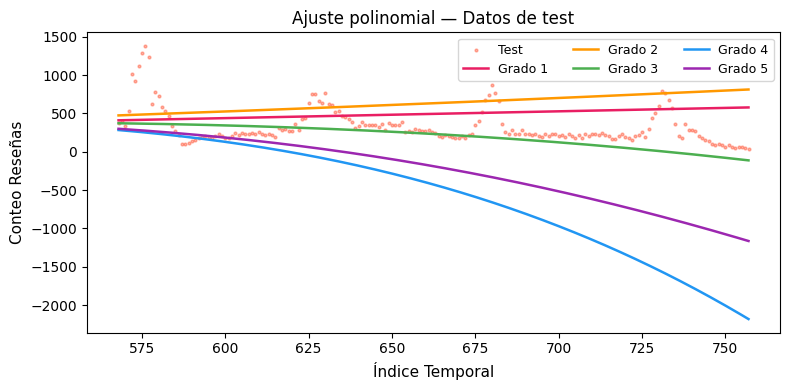

In [20]:
# Ajuste sobre datos de test
fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(x_test, y_test_vals, s=4, color="tomato", alpha=0.5, label="Test", zorder=2)

for grado, color in zip(grados, colores, strict=False):
    y_pred = np.polyval(coefs[grado], x_grid_test)
    ax.plot(x_grid_test, y_pred, color=color, lw=1.8, label=f"Grado {grado}")

ax.set_xlabel("Índice Temporal", fontsize=11)
ax.set_ylabel("Conteo Reseñas", fontsize=11)
ax.set_title("Ajuste polinomial — Datos de test", fontsize=12)
ax.legend(fontsize=9, ncol=3)
plt.tight_layout()
plt.savefig("poly_test.pdf", bbox_inches="tight", dpi=150)
plt.show()

## 3. Evaluación y selección de modelos de regresión polinomial mediante métricas de desempeño

In [21]:
# Se calculan las métricas para cada grado
resultados = []

for grado in grados:
    # Predicciones en train y test
    y_pred_train = np.polyval(coefs[grado], x_train)
    y_pred_test = np.polyval(coefs[grado], x_test)

    # Clip para evitar valores negativos en MSLE
    y_pred_test_clip = np.clip(y_pred_test, 0, None)
    y_pred_train_clip = np.clip(y_pred_train, 0, None)

    # Métricas train
    ecm_train = mean_squared_error(y_train_vals, y_pred_train)
    eam_train = mean_absolute_error(y_train_vals, y_pred_train)
    r2_train = r2_score(y_train_vals, y_pred_train)
    msle_train = np.mean((np.log1p(y_train_vals) - np.log1p(y_pred_train_clip)) ** 2)

    # Métricas test
    ecm_test = mean_squared_error(y_test_vals, y_pred_test)
    eam_test = mean_absolute_error(y_test_vals, y_pred_test)
    r2_test = r2_score(y_test_vals, y_pred_test)
    msle_test = np.mean((np.log1p(y_test_vals) - np.log1p(y_pred_test_clip)) ** 2)

    resultados.append(
        {
            "Grado": grado,
            "ECM Train": ecm_train,
            "ECM Test": ecm_test,
            "EAM Train": eam_train,
            "EAM Test": eam_test,
            "R2 Train": r2_train,
            "R2 Test": r2_test,
            "MSLE Train": msle_train,
            "MSLE Test": msle_test,
        }
    )

df_metrics = pd.DataFrame(resultados).set_index("Grado")
print(df_metrics.round(4))

        ECM Train      ECM Test  EAM Train  EAM Test  R2 Train  R2 Test  \
Grado                                                                     
1      20934.8199  8.983199e+04    87.5560  261.6607    0.5025  -0.6976   
2      20123.6360  1.715488e+05    78.2585  369.5453    0.5218  -2.2419   
3      18651.7867  6.866148e+04    75.9204  184.7807    0.5568  -0.2976   
4      17813.7613  1.322593e+06    67.5743  938.1371    0.5767 -23.9941   
5      17790.9651  5.325268e+05    68.4750  610.1482    0.5772  -9.0636   

       MSLE Train  MSLE Test  
Grado                         
1          1.7805     0.7950  
2          1.3825     1.1873  
3          1.8666     4.2479  
4          0.9239    23.3795  
5          1.2106    20.3970  


## 5. Estimación por máxima verosimilitud en un modelo no lineal y extensión con componentes sinusoidales

Se fija el polinomio de grado 3, y se programan las funcion objetivo que corresponde a la verosimilitud 

In [22]:
# Polinomio de grado 3 fijo:
coef_pol3 = coefs[3]


def f_pol3(x):
    return np.polyval(coef_pol3, x)


def f_theta(x, params):
    t1, t2, t3, t4 = params
    return f_pol3(x) + t1 * np.sin(t2 * x + t3) * np.exp(t4 * x)


# Función objetivo: log-verosimilitud negativa
def neg_log_likelihood(params):
    y_pred = f_theta(x_train, params)

    # Cortar si hay divergencia numérica
    if np.any(~np.isfinite(y_pred)):
        return 1e10

    residuos = y_train_vals - y_pred
    n = len(residuos)
    sigma2 = np.mean(residuos**2)
    if sigma2 <= 0:
        return 1e10

    nll = (n / 2) * np.log(2 * np.pi * sigma2) + (1 / (2 * sigma2)) * np.sum(residuos**2)
    return nll if np.isfinite(nll) else 1e10

Notar que la log- verosimilitud no es lineal en sus parametros, por lo tanto, el máximo no puede encontrarse de manera análitica y es bien probable que la solución no coverga, así que se debe encontrar de forma númerica, es por esto, que se procede a optimizar bajo la condición inicial sugerida, es decir $\theta_{4} = 0.01$

In [26]:
# Optimización con BFGS
theta0_base = [0.0, 0.01, 0.0, 0.0]  # theta_{4}=0.01 como sugiere el enunciado

resultado = minimize(neg_log_likelihood, x0=theta0_base, method="BFGS", options={"maxiter": 10000, "gtol": 1e-8})

theta_opt = resultado.x
print("Parámetros óptimos:", theta_opt)
print("Convergió:", resultado.success)
print("Mensaje:", resultado.message)

Parámetros óptimos: [-5.47072293e+01  2.10974849e-02 -4.30915362e+00 -3.40963805e-04]
Convergió: False
Mensaje: Desired error not necessarily achieved due to precision loss.


Se procede a ver y analizar la sensibilidad a condiciones iniciales

In [42]:
iniciales = [
    [1.0, 1.0, 0.0, 0.01],  # sugerida por enunciado
    [10.0, 0.05, 1.0, 0.01],  # amplitud alta
    [1.0, 1.0, 0.0, 0.01],  # frecuencia alta
    [0.1, 0.01, 0.0, 0.01],  # amplitud baja
    [-1.0, 0.1, np.pi, 0.01],  # amplitud negativa
    [20, 0.01, 0.0, 0.01],  # frecuencia muy alta
    [1.0, 1.0, 1.0, 50],  # amplitud muy alta
    [0.1, 0.01, 0.01, 0.1],  # frecuencia alta y amplitud muy alta
    [0.1, 0.01, 1.0, -0.5],  # frecuencia alta y amortiguamiento negativo
    [-1.0, -1.0, -1.0, -1.0],  # todas negativas
]

resultados_sens = []
for i, theta0 in enumerate(iniciales):
    res = minimize(neg_log_likelihood, x0=theta0, method="BFGS", options={"maxiter": 10000, "gtol": 1e-8})
    y_pred_test = f_theta(x_test, res.x)

    # Verificar si la predicción divergió
    if np.any(~np.isfinite(y_pred_test)) or np.any(np.abs(y_pred_test) > 1e10):
        ecm = np.inf
        convergio = False
    else:
        ecm = mean_squared_error(y_test_vals, y_pred_test)
        convergio = res.success

    resultados_sens.append({"Init": i + 1, "theta1": np.round(res.x[0], 4), "theta2": np.round(res.x[1], 4), "theta3": np.round(res.x[2], 4), "theta4": np.round(res.x[3], 6), "NLL": res.fun, "ECM Test": ecm, "Convergió": convergio})

df_sens = pd.DataFrame(resultados_sens).set_index("Init")
print(df_sens.round(4))

/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/2583377268.py:24: RuntimeWarning: overflow encountered in square
  sigma2 = np.mean(residuos**2)
/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/2583377268.py:28: RuntimeWarning: overflow encountered in square
  nll = (n / 2) * np.log(2 * np.pi * sigma2) + (1 / (2 * sigma2)) * np.sum(residuos**2)
/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/2583377268.py:28: RuntimeWarning: invalid value encountered in scalar multiply
  nll = (n / 2) * np.log(2 * np.pi * sigma2) + (1 / (2 * sigma2)) * np.sum(residuos**2)
/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/2583377268.py:24: RuntimeWarning: overflow encountered in square
  sigma2 = np.mean(residuos**2)
/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/2583377268.py:28: RuntimeWarning: overflow encountered in square
  nll = (n / 2) * np.log(2 * np.pi * sigma2) + (1 / (2 * sigma2)) * np.sum(residuos**2)
/var/folders/

         theta1   theta2  theta3   theta4           NLL    ECM Test  Convergió
Init                                                                          
1     -824.0025  12.5532 -9.4862  -0.1050  3.590781e+03  68661.4808      False
2     1068.8276  -0.4064  0.2268  -1.0765  3.592052e+03  68661.4808      False
3     -824.0025  12.5532 -9.4862  -0.1050  3.590781e+03  68661.4808      False
4       54.7053  -6.2621  5.1156  -0.0003  3.573881e+03  64897.8999      False
5     -281.3011  -0.8611  3.2304  -1.1955  3.592201e+03  68661.4808      False
6     1337.8966   0.3227 -3.3478  -0.9723  3.592006e+03  68661.4808      False
7        1.0000   1.0000  1.0000  50.0000  1.000000e+10         inf      False
8      -54.7075   0.0211  1.9740  -0.0003  3.573881e+03  64897.9780      False
9      -54.7055  -0.0211  1.1676  -0.0003  3.573881e+03  64897.8614      False
10      -4.3868   0.0558 -5.6804   0.0045  3.587836e+03  68181.9180      False


/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/2583377268.py:11: RuntimeWarning: overflow encountered in exp
  return f_pol3(x) + t1 * np.sin(t2 * x + t3) * np.exp(t4 * x)
/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/2583377268.py:11: RuntimeWarning: overflow encountered in multiply
  return f_pol3(x) + t1 * np.sin(t2 * x + t3) * np.exp(t4 * x)
/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/2583377268.py:24: RuntimeWarning: overflow encountered in square
  sigma2 = np.mean(residuos**2)
/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/2583377268.py:28: RuntimeWarning: overflow encountered in square
  nll = (n / 2) * np.log(2 * np.pi * sigma2) + (1 / (2 * sigma2)) * np.sum(residuos**2)
/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/2583377268.py:28: RuntimeWarning: invalid value encountered in scalar multiply
  nll = (n / 2) * np.log(2 * np.pi * sigma2) + (1 / (2 * sigma2)) * np.sum(residuos**2)


In [45]:
# Identificar la mejor condición inicial según ECM Test
df_sens_finito = df_sens[df_sens["ECM Test"] != np.inf]
mejor_init = df_sens_finito["ECM Test"].idxmin()
mejor_theta = [df_sens.loc[mejor_init, "theta1"], df_sens.loc[mejor_init, "theta2"], df_sens.loc[mejor_init, "theta3"], df_sens.loc[mejor_init, "theta4"]]

print(f"Mejor condición inicial: Init {mejor_init}")
print(f"Theta óptimo: {mejor_theta}")

Mejor condición inicial: Init 9
Theta óptimo: [np.float64(-54.7055), np.float64(-0.0211), np.float64(1.1676), np.float64(-0.000341)]


Se imprimen las métricas que obtuvieron el mejor resultado

In [46]:
# Métricas del mejor resultado
def calcular_metricas(y_true, y_pred, nombre=""):
    y_pred_clip = np.clip(y_pred, 0, None)
    y_true_clip = np.clip(y_true, 0, None)

    ecm = mean_squared_error(y_true, y_pred)
    eam = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    msle = np.mean((np.log1p(y_true_clip) - np.log1p(y_pred_clip)) ** 2)

    print(f"\n--- Métricas {nombre} ---")
    print(f"ECM : {ecm:.2f}")
    print(f"EAM : {eam:.2f}")
    print(f"R2  : {r2:.4f}")
    print(f"MSLE: {msle:.4f}")
    return ecm, eam, r2, msle


# Re-optimizar desde la mejor condición inicial
res_mejor = minimize(neg_log_likelihood, x0=iniciales[mejor_init - 1], method="BFGS", options={"maxiter": 10000, "gtol": 1e-8})
theta_opt = res_mejor.x

y_pred_train_opt = f_theta(x_train, theta_opt)
y_pred_test_opt = f_theta(x_test, theta_opt)

print(f"\nTheta óptimo (Init {mejor_init}): {theta_opt.round(4)}")
calcular_metricas(y_train_vals, y_pred_train_opt, "Train")
calcular_metricas(y_test_vals, y_pred_test_opt, "Test")


Theta óptimo (Init 9): [-5.47055e+01 -2.11000e-02  1.16760e+00 -3.00000e-04]

--- Métricas Train ---
ECM : 17472.89
EAM : 69.23
R2  : 0.5848
MSLE: 1.1056

--- Métricas Test ---
ECM : 64897.86
EAM : 167.48
R2  : -0.2264
MSLE: 2.5569


/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/2583377268.py:24: RuntimeWarning: overflow encountered in square
  sigma2 = np.mean(residuos**2)
/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/2583377268.py:28: RuntimeWarning: overflow encountered in square
  nll = (n / 2) * np.log(2 * np.pi * sigma2) + (1 / (2 * sigma2)) * np.sum(residuos**2)
/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/2583377268.py:28: RuntimeWarning: invalid value encountered in scalar multiply
  nll = (n / 2) * np.log(2 * np.pi * sigma2) + (1 / (2 * sigma2)) * np.sum(residuos**2)
/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/2583377268.py:11: RuntimeWarning: overflow encountered in exp
  return f_pol3(x) + t1 * np.sin(t2 * x + t3) * np.exp(t4 * x)
/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/2583377268.py:11: RuntimeWarning: overflow encountered in multiply
  return f_pol3(x) + t1 * np.sin(t2 * x + t3) * np.exp(t4 * x)


(64897.8614193294,
 167.47892885403797,
 -0.22642593889768237,
 np.float64(2.5569152296149835))

## 6. Estimación por máxima verosimilitud en un modelo no lineal y extensión con componentes sinusoidales adicionales

Se crea función verosimilitud con los parametros óptimos anteriores más la segunda componente sinusoidal

In [48]:
# Modelo completo: pol-sin fijo + segunda sinusoidal
def f_polsin(x):
    """f^pol-sin con parámetros fijos de la parte anterior."""
    t1, t2, t3, t4 = theta_opt  # parámetros fijos
    return f_pol3(x) + t1 * np.sin(t2 * x + t3) * np.exp(t4 * x)


def f_theta2(x, params):
    """Modelo completo: f^pol-sin + segunda componente sinusoidal."""
    t5, t6, t7, t8 = params
    return f_polsin(x) + t5 * np.sin(t6 * x + t7) * np.exp(t8 * x)


# Función objetivo: negative log-likelihood
def neg_log_likelihood2(params):
    y_pred = f_theta2(x_train, params)
    if np.any(~np.isfinite(y_pred)):
        return 1e10
    residuos = y_train_vals - y_pred
    sigma2 = np.mean(residuos**2)
    if sigma2 <= 0:
        return 1e10
    nll = (len(residuos) / 2) * np.log(2 * np.pi * sigma2) + (1 / (2 * sigma2)) * np.sum(residuos**2)
    return nll if np.isfinite(nll) else 1e10

In [49]:
# Condición inicial sugerida por el enunciado
theta0_2 = [1.0, 0.1, 0.0, 0.01]  # t8=0.01 como sugiere enunciado

# Optimización con tres métodos
metodos = {
    "BFGS": {"method": "BFGS", "options": {"maxiter": 10000, "gtol": 1e-8}},
    "Nelder-Mead": {"method": "Nelder-Mead", "options": {"maxiter": 50000, "xatol": 1e-8, "fatol": 1e-8}},
    "L-BFGS-B": {"method": "L-BFGS-B", "options": {"maxiter": 10000, "ftol": 1e-12, "gtol": 1e-8}},
}

resultados_metodos = {}

for nombre, kwargs in metodos.items():
    res = minimize(neg_log_likelihood2, x0=theta0_2, **kwargs)

    y_pred_train = f_theta2(x_train, res.x)
    y_pred_test = f_theta2(x_test, res.x)

    # Verificar divergencia
    if np.any(~np.isfinite(y_pred_test)) or np.any(np.abs(y_pred_test) > 1e10):
        ecm_te, eam_te, r2_te, msle_te = np.inf, np.inf, np.inf, np.inf
        ecm_tr, eam_tr, r2_tr, msle_tr = np.inf, np.inf, np.inf, np.inf
    else:
        ecm_tr = mean_squared_error(y_train_vals, y_pred_train)
        eam_tr = mean_absolute_error(y_train_vals, y_pred_train)
        r2_tr = r2_score(y_train_vals, y_pred_train)
        msle_tr = np.mean((np.log1p(np.clip(y_train_vals, 0, None)) - np.log1p(np.clip(y_pred_train, 0, None))) ** 2)
        ecm_te = mean_squared_error(y_test_vals, y_pred_test)
        eam_te = mean_absolute_error(y_test_vals, y_pred_test)
        r2_te = r2_score(y_test_vals, y_pred_test)
        msle_te = np.mean((np.log1p(np.clip(y_test_vals, 0, None)) - np.log1p(np.clip(y_pred_test, 0, None))) ** 2)

    resultados_metodos[nombre] = {
        "theta5": res.x[0],
        "theta6": res.x[1],
        "theta7": res.x[2],
        "theta8": res.x[3],
        "NLL": res.fun,
        "Iters": res.nit,
        "Evals": res.nfev,
        "Convergió": res.success,
        "ECM Tr": ecm_tr,
        "EAM Tr": eam_tr,
        "R2 Tr": r2_tr,
        "MSLE Tr": msle_tr,
        "ECM Te": ecm_te,
        "EAM Te": eam_te,
        "R2 Te": r2_te,
        "MSLE Te": msle_te,
    }

    print(f"\n{'=' * 50}")
    print(f"Método: {nombre}")
    print(f"Convergió : {res.success} | Iters: {res.nit} | Evals: {res.nfev}")
    print(f"Parámetros: θ5={res.x[0]:.4f}, θ6={res.x[1]:.4f}, θ7={res.x[2]:.4f}, θ8={res.x[3]:.6f}")
    print(f"NLL       : {res.fun:.4f}")
    print(f"--- Train --- ECM:{ecm_tr:.2f} EAM:{eam_tr:.2f} R2:{r2_tr:.4f} MSLE:{msle_tr:.4f}")
    print(f"--- Test  --- ECM:{ecm_te:.2f} EAM:{eam_te:.2f} R2:{r2_te:.4f} MSLE:{msle_te:.4f}")

df_metodos = pd.DataFrame(resultados_metodos).T
print("\n", df_metodos.round(4))


Método: BFGS
Convergió : False | Iters: 123 | Evals: 1252
Parámetros: θ5=55.3905, θ6=-0.1126, θ7=-0.1446, θ8=-0.217946
NLL       : 3573.8479
--- Train --- ECM:17470.84 EAM:69.07 R2:0.5848 MSLE:1.0622
--- Test  --- ECM:64897.86 EAM:167.48 R2:-0.2264 MSLE:2.5569

Método: Nelder-Mead
Convergió : True | Iters: 438 | Evals: 791
Parámetros: θ5=24.8120, θ6=0.1205, θ7=-11.4405, θ8=0.003605
NLL       : 3493.0570
--- Train --- ECM:13138.63 EAM:63.27 R2:0.6878 MSLE:1.4021
--- Test  --- ECM:52958.02 EAM:175.20 R2:-0.0008 MSLE:5.3472

Método: L-BFGS-B
Convergió : False | Iters: 7 | Evals: 490
Parámetros: θ5=13.6804, θ6=0.1779, θ7=-3.2156, θ8=-0.006243
NLL       : 3573.7167
--- Train --- ECM:17462.86 EAM:69.41 R2:0.5850 MSLE:1.1120
--- Test  --- ECM:64919.64 EAM:167.51 R2:-0.2268 MSLE:2.5555

                 theta5    theta6    theta7    theta8          NLL Iters Evals  \
BFGS         55.390507 -0.112586 -0.144607 -0.217946  3573.847889   123  1252   
Nelder-Mead  24.811998  0.120482 -11.44052  0.

/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/3345815436.py:10: RuntimeWarning: overflow encountered in exp
  return f_polsin(x) + t5 * np.sin(t6 * x + t7) * np.exp(t8 * x)
/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/3345815436.py:19: RuntimeWarning: overflow encountered in square
  sigma2 = np.mean(residuos**2)
/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/3345815436.py:23: RuntimeWarning: overflow encountered in square
  (1 / (2 * sigma2)) * np.sum(residuos**2)
/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/3345815436.py:23: RuntimeWarning: invalid value encountered in scalar multiply
  (1 / (2 * sigma2)) * np.sum(residuos**2)
/var/folders/c5/g_hqy45s36jc0_wcl6j0lzsm0000gn/T/ipykernel_1249/3345815436.py:10: RuntimeWarning: overflow encountered in multiply
  return f_polsin(x) + t5 * np.sin(t6 * x + t7) * np.exp(t8 * x)


In [50]:
# Seleccionar mejor método según ECM Test
df_finito = df_metodos[df_metodos["ECM Te"] != np.inf]
mejor_metodo = df_finito["ECM Te"].idxmin()
theta_opt2 = df_metodos.loc[mejor_metodo, ["theta5", "theta6", "theta7", "theta8"]].values.astype(float)

print(f"\nMejor método: {mejor_metodo}")
print(f"Theta óptimo: {theta_opt2.round(4)}")


Mejor método: Nelder-Mead
Theta óptimo: [ 2.48120e+01  1.20500e-01 -1.14405e+01  3.60000e-03]


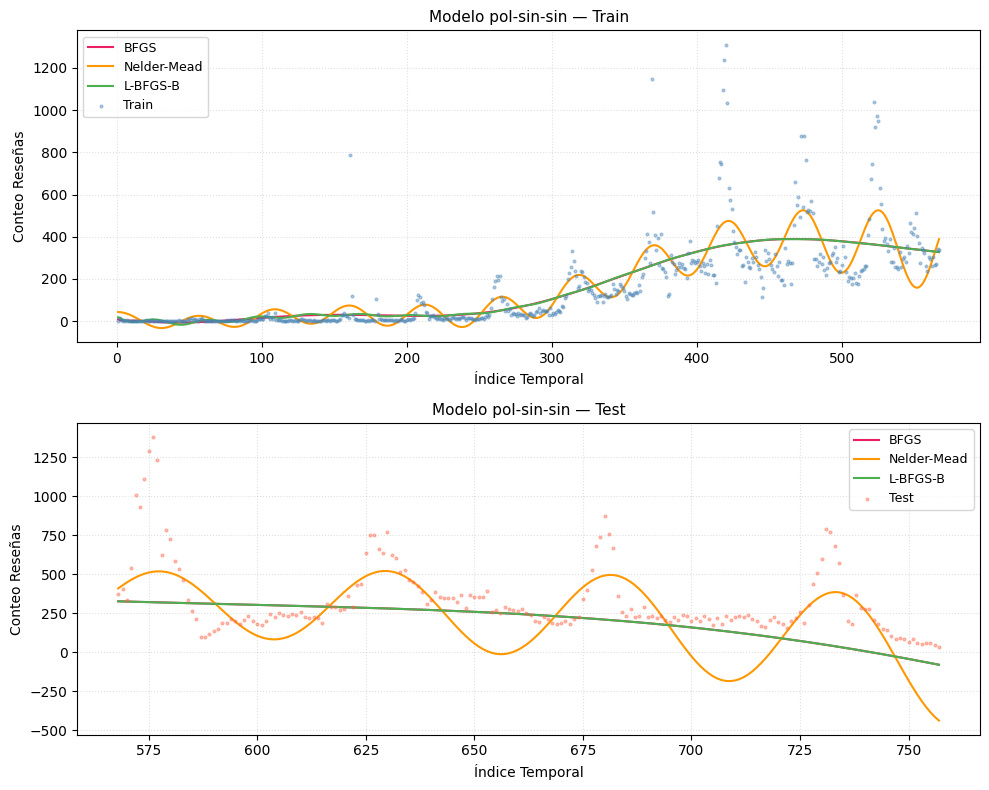

In [51]:
# Gráfico comparativo de los tres métodos
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
colores_m = {"BFGS": "#E91E63", "Nelder-Mead": "#FF9800", "L-BFGS-B": "#4CAF50"}

for nombre, res_dict in resultados_metodos.items():
    params = [res_dict["theta5"], res_dict["theta6"], res_dict["theta7"], res_dict["theta8"]]

    y_tr = f_theta2(x_train, params)
    y_te = f_theta2(x_test, params)

    axes[0].plot(x_train, y_tr, lw=1.5, color=colores_m[nombre], label=nombre)
    axes[1].plot(x_test, y_te, lw=1.5, color=colores_m[nombre], label=nombre)

# Datos reales
axes[0].scatter(x_train, y_train_vals, s=4, color="steelblue", alpha=0.4, label="Train", zorder=2)
axes[1].scatter(x_test, y_test_vals, s=4, color="tomato", alpha=0.4, label="Test", zorder=2)

for ax, titulo in zip(axes, ["Train", "Test"], strict=False):
    ax.set_title(f"Modelo pol-sin-sin — {titulo}", fontsize=11)
    ax.set_xlabel("Índice Temporal", fontsize=10)
    ax.set_ylabel("Conteo Reseñas", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, ls=":", alpha=0.4)

plt.tight_layout()
plt.savefig("ajuste_polsinsin.pdf", bbox_inches="tight", dpi=150)
plt.show()